In [219]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns


In [220]:
data=pd.read_csv("/content/flipkart_product.csv", encoding='ISO-8859-1')
df=pd.DataFrame(data)
print(df.isnull().sum())
print(df.shape)
df.dropna(axis=0,inplace=True)
print(df["Rate"].dtype)

print(df["Rate"].unique())
df = df[df["Rate"].isin(["1","2","3","4","5"])]
df["Rate"] = df["Rate"].astype(int)
def sentiment(rate):
    if rate <= 2:
        return "Negative"
    elif rate == 3:
        return "Neutral"
    else:
        return "Positive"

df["Sentiment"] = df["Rate"].apply(sentiment)
import re

def clean_text(text):
    text = text.lower()

    text = re.sub(r'\d+', '', text)

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    return text

df["clean_review"] = df["Summary"].apply(clean_text)
print(df.head())

ProductName     0
Price           1
Rate            1
Review          4
Summary        14
dtype: int64
(189874, 5)
object
['5' '3' '1' '4' '2'
 'Pigeon Favourite Electric Kettle?ÿ?ÿ(1.5 L, Silver, Black)'
 'Bajaj DX 2 L/W Dry Iron'
 'Nova Plus Amaze NI 10 1100 W Dry Iron?ÿ?ÿ(Grey & Turquoise)' 's']
                                         ProductName     Price  Rate  \
0  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...  ??3,999     5   
1  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...  ??3,999     5   
2  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...  ??3,999     3   
3  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...  ??3,999     1   
4  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...  ??3,999     3   

            Review                                            Summary  \
0           Super!  Great cooler.. excellent air flow and for this...   
1          Awesome             Best budget 2 fit cooler. Nice cooling   
2             Fair  The quality is good but the 

In [221]:

df['ProductName'] = df['ProductName'].str.replace(r'[?ÿ]+', '', regex=True)


df['Price'] = df['Price'].str.replace(r'[^\d,]', '', regex=True)
df['Price'] = df['Price'].str.replace(',', '').astype(int)

print(df.head())
df.head()

                                         ProductName  Price  Rate  \
0  Candes 12 L Room/Personal Air Cooler(White, Bl...   3999     5   
1  Candes 12 L Room/Personal Air Cooler(White, Bl...   3999     5   
2  Candes 12 L Room/Personal Air Cooler(White, Bl...   3999     3   
3  Candes 12 L Room/Personal Air Cooler(White, Bl...   3999     1   
4  Candes 12 L Room/Personal Air Cooler(White, Bl...   3999     3   

            Review                                            Summary  \
0           Super!  Great cooler.. excellent air flow and for this...   
1          Awesome             Best budget 2 fit cooler. Nice cooling   
2             Fair  The quality is good but the power of air is de...   
3  Useless product                 Very bad product it's a only a fan   
4             Fair                                      Ok ok product   

  Sentiment                                       clean_review  
0  Positive  great cooler excellent air flow and for this p...  
1  Positive     

,ProductName,Price,Rate,Review,Summary,Sentiment,clean_review
0,"Candes 12 L Room/Personal Air Cooler(White, Bl...",3999,5,Super!,Great cooler.. excellent air flow and for this...,Positive,great cooler excellent air flow and for this p...
1,"Candes 12 L Room/Personal Air Cooler(White, Bl...",3999,5,Awesome,Best budget 2 fit cooler. Nice cooling,Positive,best budget fit cooler nice cooling
2,"Candes 12 L Room/Personal Air Cooler(White, Bl...",3999,3,Fair,The quality is good but the power of air is de...,Neutral,the quality is good but the power of air is de...
3,"Candes 12 L Room/Personal Air Cooler(White, Bl...",3999,1,Useless product,Very bad product it's a only a fan,Negative,very bad product its a only a fan
4,"Candes 12 L Room/Personal Air Cooler(White, Bl...",3999,3,Fair,Ok ok product,Neutral,ok ok product


In [222]:
X_train,X_test,Y_train,Y_test=train_test_split(df["clean_review"],df["Sentiment"],test_size=0.2,random_state=42)
vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=5000
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
model=MultinomialNB()
model.fit(X_train_vec,Y_train)
Y_pred=model.predict(X_test_vec)
feature_names = vectorizer.get_feature_names_out()
print("feature names",feature_names)
print("accuracy",accuracy_score(Y_test,Y_pred))
print("classification report\n",classification_report(Y_test,Y_pred))


feature names ['ability' 'able' 'able use' ... 'zero' 'zip' 'zoom']
accuracy 0.856390403202444
classification report
               precision    recall  f1-score   support

    Negative       0.83      0.68      0.75      5318
     Neutral       0.33      0.23      0.27      3080
    Positive       0.90      0.95      0.92     29573

    accuracy                           0.86     37971
   macro avg       0.69      0.62      0.65     37971
weighted avg       0.84      0.86      0.85     37971



In [223]:
X_train,X_test,Y_train,Y_test=train_test_split(df["clean_review"],df["Sentiment"],test_size=0.2,random_state=42)
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=5000
)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
model=MultinomialNB()
model.fit(X_train_vec,Y_train)
Y_pred=model.predict(X_test_vec)
print(classification_report(Y_test,Y_pred))

              precision    recall  f1-score   support

    Negative       0.82      0.67      0.74      5318
     Neutral       0.48      0.11      0.18      3080
    Positive       0.88      0.98      0.93     29573

    accuracy                           0.87     37971
   macro avg       0.73      0.59      0.62     37971
weighted avg       0.84      0.87      0.84     37971



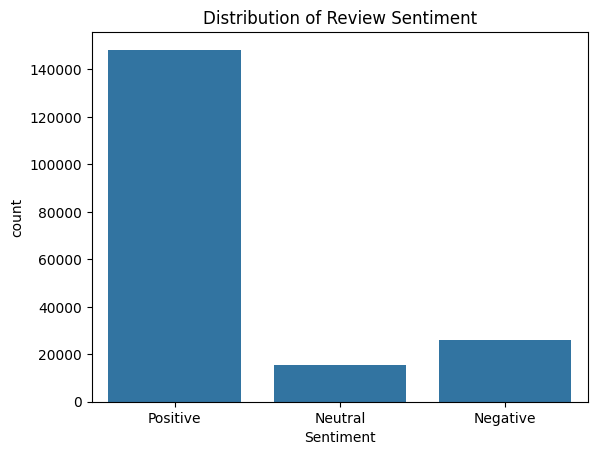

In [224]:
sns.countplot(
    x="Sentiment",
    data=df
)
plt.title("Distribution of Review Sentiment")
plt.show()

In [225]:
avg_price = df.groupby("Sentiment")["Price"].mean()
print(avg_price)

Sentiment
Negative    2992.208707
Neutral     3026.016454
Positive    4723.471763
Name: Price, dtype: float64


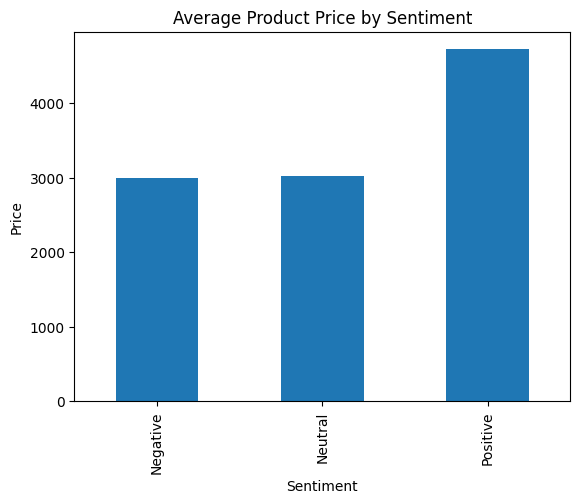

In [226]:
avg_price.plot(kind="bar")
plt.title("Average Product Price by Sentiment")
plt.ylabel("Price")
plt.show()

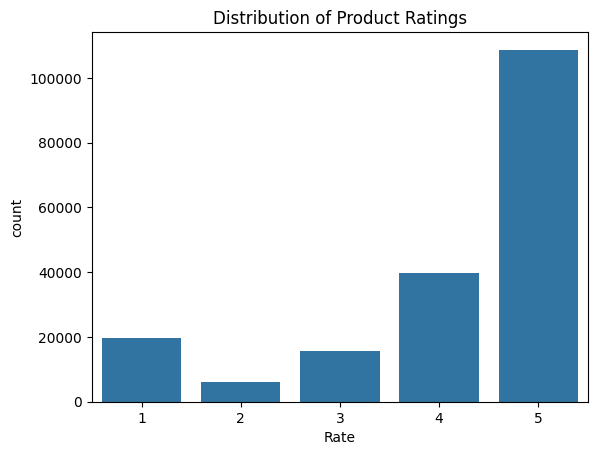

In [227]:
sns.countplot(
    x="Rate",
    data=df
)
plt.title("Distribution of Product Ratings")
plt.show()

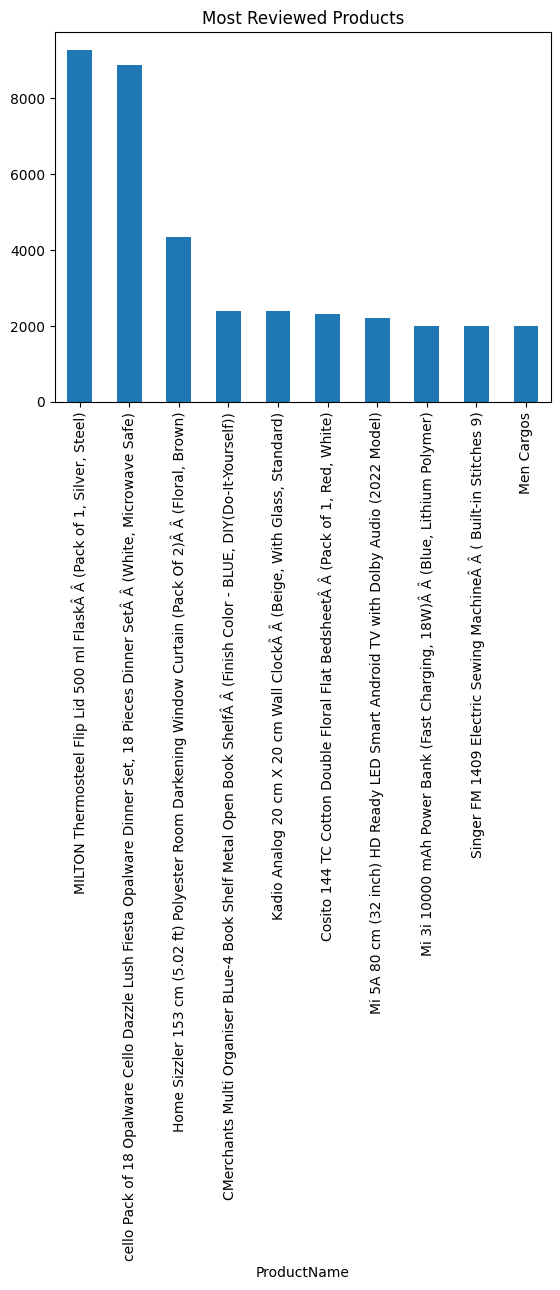

In [228]:
top_products = df["ProductName"].value_counts().head(10)

top_products.plot(kind="bar")
plt.title("Most Reviewed Products")
plt.show()

In [229]:
top_rated = (
    df.groupby("ProductName")["Rate"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

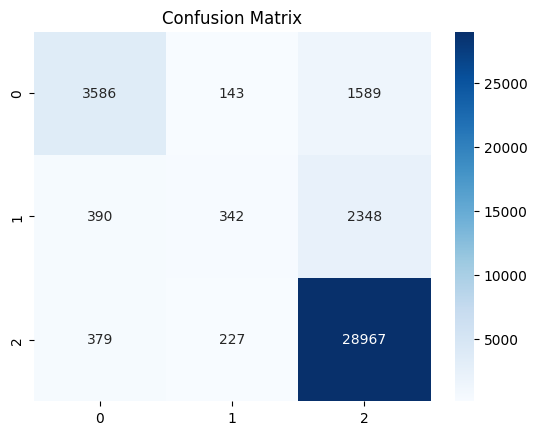

In [230]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test,Y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

<Axes: xlabel='Sentiment', ylabel='review_length'>

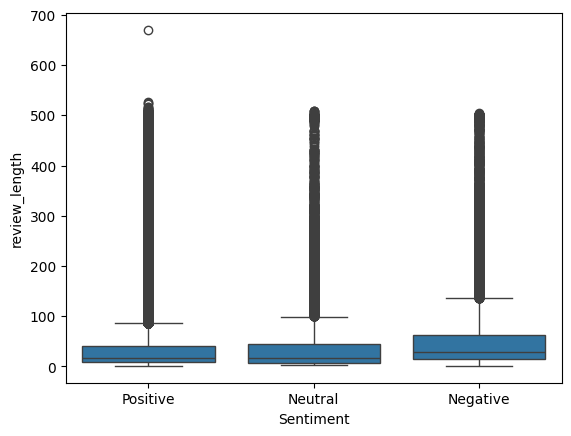

In [231]:
df["review_length"] = df["Summary"].apply(len)
sns.boxplot(
    x="Sentiment",
    y="review_length",
    data=df
)